<a href="https://colab.research.google.com/github/potgieterphiline/MBDS/blob/main/MIT801_ML_Assignment_1.2_PhilinePotgieter_u27043275.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [ ]:
import os
import time
import re
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve
)

from scipy.sparse import vstack

!pip install gensim
!pip install sentence-transformers
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api
from sentence_transformers import SentenceTransformer

nltk.download('punkt_tab')


# Stage 1: Data Loading and Preprocessing

In [ ]:
folder_path_neg = 'negx'
folder_path_pos = 'pos'

In [ ]:
data_neg = []

for filename in os.listdir(folder_path_neg):
    if filename.endswith('.txt'):
        filepath = os.path.join(folder_path_neg, filename)
        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()
        data_neg.append({'filename': filename, 'content': content})

df_sentiment_neg = pd.DataFrame(data_neg)

display(df_sentiment_neg.head())
df_sentiment_neg.shape

,filename,content
0,cv272_20313.txt,i'm a dedicated fan of writer kevin williamson...
1,cv896_17819.txt,what would inspire someone who cannot write or...
2,cv962_9813.txt,humanities quest for knowledge never ends . \n...
3,cv076_26009.txt,"susan granger's review of "" the watcher "" ( un..."
4,cv097_26081.txt,another formula 'feel good' quirky comedy from...


(1000, 2)

In [ ]:
data_pos = []

for filename in os.listdir(folder_path_pos):
    if filename.endswith('.txt'):
        filepath = os.path.join(folder_path_pos, filename)
        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()
        data_pos.append({'filename': filename, 'content': content})

df_sentiment_pos = pd.DataFrame(data_pos)

display(df_sentiment_pos.head())
df_sentiment_pos.shape

,filename,content
0,cv261_10954.txt,titanic is so close to being the perfect movie...
1,cv918_2693.txt,wyatt earp has a lot to tell and little to say...
2,cv735_18801.txt,"vannesa kensington : `austin , do you smoke af..."
3,cv211_9953.txt,"with the success of the surprise hit alien , d..."
4,cv547_16324.txt,"steve soderbergh's "" sex , lies , and videotap..."


(1000, 2)

##i) Tokenisation and lowercasing

In [ ]:
def tokenize_text(text):
    return word_tokenize(text.lower())

df_sentiment_pos['tokenized_content'] = df_sentiment_pos['content'].apply(tokenize_text)

display(df_sentiment_pos.head())
df_sentiment_pos.shape

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,filename,content,tokenized_content
0,cv261_10954.txt,titanic is so close to being the perfect movie...,"[titanic, is, so, close, to, being, the, perfe..."
1,cv918_2693.txt,wyatt earp has a lot to tell and little to say...,"[wyatt, earp, has, a, lot, to, tell, and, litt..."
2,cv735_18801.txt,"vannesa kensington : `austin , do you smoke af...","[vannesa, kensington, :, `, austin, ,, do, you..."
3,cv211_9953.txt,"with the success of the surprise hit alien , d...","[with, the, success, of, the, surprise, hit, a..."
4,cv547_16324.txt,"steve soderbergh's "" sex , lies , and videotap...","[steve, soderbergh, 's, ``, sex, ,, lies, ,, a..."


(1000, 3)

In [ ]:
def tokenize_text(text):
    return word_tokenize(text.lower())

df_sentiment_neg['tokenized_content'] = df_sentiment_neg['content'].apply(tokenize_text)

display(df_sentiment_neg.head())
df_sentiment_pos.shape

,filename,content,tokenized_content
0,cv272_20313.txt,i'm a dedicated fan of writer kevin williamson...,"[i, 'm, a, dedicated, fan, of, writer, kevin, ..."
1,cv896_17819.txt,what would inspire someone who cannot write or...,"[what, would, inspire, someone, who, can, not,..."
2,cv962_9813.txt,humanities quest for knowledge never ends . \n...,"[humanities, quest, for, knowledge, never, end..."
3,cv076_26009.txt,"susan granger's review of "" the watcher "" ( un...","[susan, granger, 's, review, of, ``, the, watc..."
4,cv097_26081.txt,another formula 'feel good' quirky comedy from...,"[another, formula, 'feel, good, ', quirky, com..."


(1000, 3)

## ii) Stopword removal

In [ ]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df_sentiment_pos['filtered_content'] = df_sentiment_pos['tokenized_content'].apply(remove_stopwords)
df_sentiment_neg['filtered_content'] = df_sentiment_neg['tokenized_content'].apply(remove_stopwords)

## iii) Lemmatisation

In [ ]:
lemmatizer = WordNetLemmatizer()

In [ ]:
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df_sentiment_pos['lemmatized_content'] = df_sentiment_pos['filtered_content'].apply(lemmatize_tokens)
df_sentiment_neg['lemmatized_content'] = df_sentiment_neg['filtered_content'].apply(lemmatize_tokens)

In [ ]:
display(df_sentiment_pos.head())
display(df_sentiment_neg.head())

display(df_sentiment_pos.shape)
display(df_sentiment_neg.shape)

,filename,content,tokenized_content,filtered_content,lemmatized_content
0,cv261_10954.txt,titanic is so close to being the perfect movie...,"[titanic, is, so, close, to, being, the, perfe...","[titanic, close, perfect, movie, 's, upsetting...","[titanic, close, perfect, movie, 's, upsetting..."
1,cv918_2693.txt,wyatt earp has a lot to tell and little to say...,"[wyatt, earp, has, a, lot, to, tell, and, litt...","[wyatt, earp, lot, tell, little, say, ., story...","[wyatt, earp, lot, tell, little, say, ., story..."
2,cv735_18801.txt,"vannesa kensington : `austin , do you smoke af...","[vannesa, kensington, :, `, austin, ,, do, you...","[vannesa, kensington, :, `, austin, ,, smoke, ...","[vannesa, kensington, :, `, austin, ,, smoke, ..."
3,cv211_9953.txt,"with the success of the surprise hit alien , d...","[with, the, success, of, the, surprise, hit, a...","[success, surprise, hit, alien, ,, directed, r...","[success, surprise, hit, alien, ,, directed, r..."
4,cv547_16324.txt,"steve soderbergh's "" sex , lies , and videotap...","[steve, soderbergh, 's, ``, sex, ,, lies, ,, a...","[steve, soderbergh, 's, ``, sex, ,, lies, ,, v...","[steve, soderbergh, 's, ``, sex, ,, lie, ,, vi..."


,filename,content,tokenized_content,filtered_content,lemmatized_content
0,cv272_20313.txt,i'm a dedicated fan of writer kevin williamson...,"[i, 'm, a, dedicated, fan, of, writer, kevin, ...","['m, dedicated, fan, writer, kevin, williamson...","['m, dedicated, fan, writer, kevin, williamson..."
1,cv896_17819.txt,what would inspire someone who cannot write or...,"[what, would, inspire, someone, who, can, not,...","[would, inspire, someone, write, act, pen, sta...","[would, inspire, someone, write, act, pen, sta..."
2,cv962_9813.txt,humanities quest for knowledge never ends . \n...,"[humanities, quest, for, knowledge, never, end...","[humanities, quest, knowledge, never, ends, .,...","[humanity, quest, knowledge, never, end, ., te..."
3,cv076_26009.txt,"susan granger's review of "" the watcher "" ( un...","[susan, granger, 's, review, of, ``, the, watc...","[susan, granger, 's, review, ``, watcher, ``, ...","[susan, granger, 's, review, ``, watcher, ``, ..."
4,cv097_26081.txt,another formula 'feel good' quirky comedy from...,"[another, formula, 'feel, good, ', quirky, com...","[another, formula, 'feel, good, ', quirky, com...","[another, formula, 'feel, good, ', quirky, com..."


(1000, 5)

(1000, 5)

In [ ]:
df_sentiment_pos['sentiment'] = 'positive'
df_sentiment_neg['sentiment'] = 'negative'

In [ ]:
df_sentiment = pd.concat([df_sentiment_pos, df_sentiment_neg], ignore_index=True)

display(df_sentiment.head())

display(df_sentiment['sentiment'].value_counts())

,filename,content,tokenized_content,filtered_content,lemmatized_content,sentiment
0,cv261_10954.txt,titanic is so close to being the perfect movie...,"[titanic, is, so, close, to, being, the, perfe...","[titanic, close, perfect, movie, 's, upsetting...","[titanic, close, perfect, movie, 's, upsetting...",positive
1,cv918_2693.txt,wyatt earp has a lot to tell and little to say...,"[wyatt, earp, has, a, lot, to, tell, and, litt...","[wyatt, earp, lot, tell, little, say, ., story...","[wyatt, earp, lot, tell, little, say, ., story...",positive
2,cv735_18801.txt,"vannesa kensington : `austin , do you smoke af...","[vannesa, kensington, :, `, austin, ,, do, you...","[vannesa, kensington, :, `, austin, ,, smoke, ...","[vannesa, kensington, :, `, austin, ,, smoke, ...",positive
3,cv211_9953.txt,"with the success of the surprise hit alien , d...","[with, the, success, of, the, surprise, hit, a...","[success, surprise, hit, alien, ,, directed, r...","[success, surprise, hit, alien, ,, directed, r...",positive
4,cv547_16324.txt,"steve soderbergh's "" sex , lies , and videotap...","[steve, soderbergh, 's, ``, sex, ,, lies, ,, a...","[steve, soderbergh, 's, ``, sex, ,, lies, ,, v...","[steve, soderbergh, 's, ``, sex, ,, lie, ,, vi...",positive


,count
sentiment,
positive,1000
negative,1000


## iv) Splitting data into Training, Validation and Test sets using stratified sampling.

In [ ]:
X = df_sentiment.drop('sentiment', axis=1)
y = df_sentiment['sentiment']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

df_original_counts = y.value_counts().rename('Count')
df_original_proportions = y.value_counts(normalize=True).rename('Proportion')
df_original = pd.concat([df_original_counts, df_original_proportions], axis=1).assign(Dataset='Original')

df_train_counts = y_train.value_counts().rename('Count')
df_train_proportions = y_train.value_counts(normalize=True).rename('Proportion')
df_train = pd.concat([df_train_counts, df_train_proportions], axis=1).assign(Dataset='Training (70%)')

df_val_counts = y_val.value_counts().rename('Count')
df_val_proportions = y_val.value_counts(normalize=True).rename('Proportion')
df_val = pd.concat([df_val_counts, df_val_proportions], axis=1).assign(Dataset='Validation (15%)')

df_test_counts = y_test.value_counts().rename('Count')
df_test_proportions = y_test.value_counts(normalize=True).rename('Proportion')
df_test = pd.concat([df_test_counts, df_test_proportions], axis=1).assign(Dataset='Testing (15%)')

full_distribution_table = pd.concat([df_original, df_train, df_val, df_test])
full_distribution_table = full_distribution_table.reset_index().rename(columns={'index': 'sentiment'})

full_distribution_table = full_distribution_table[['Dataset', 'sentiment', 'Count', 'Proportion']]

display(full_distribution_table)


,Dataset,sentiment,Count,Proportion
0,Original,positive,1000,0.5
1,Original,negative,1000,0.5
2,Training (70%),negative,700,0.5
3,Training (70%),positive,700,0.5
4,Validation (15%),positive,150,0.5
5,Validation (15%),negative,150,0.5
6,Testing (15%),positive,150,0.5
7,Testing (15%),negative,150,0.5


# Stage 2: Feature Extraction

## i) TF-IDF Vectorisation

In [ ]:
X_train['lemmatized_content_str'] = X_train['lemmatized_content'].apply(lambda x: ' '.join(x))
X_val['lemmatized_content_str'] = X_val['lemmatized_content'].apply(lambda x: ' '.join(x))
X_test['lemmatized_content_str'] = X_test['lemmatized_content'].apply(lambda x: ' '.join(x))

tfidf_vectorizer = TfidfVectorizer(max_df=0.7)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train['lemmatized_content_str'])

X_val_tfidf = tfidf_vectorizer.transform(X_val['lemmatized_content_str'])
X_test_tfidf = tfidf_vectorizer.transform(X_test['lemmatized_content_str'])

vocabulary_size = len(tfidf_vectorizer.vocabulary_)
max_df_threshold = tfidf_vectorizer.max_df
dimensionality = X_train_tfidf.shape

tfidf_report = pd.DataFrame({
    'Metric': ['Vocabulary Size', 'Maximum Document Frequency Threshold', 'Dimensionality (samples, features)'],
    'Value': [vocabulary_size, max_df_threshold, dimensionality]
})

display(tfidf_report)

,Metric,Value
0,Vocabulary Size,30673
1,Maximum Document Frequency Threshold,0.7
2,"Dimensionality (samples, features)","(1400, 30673)"


## ii) Embedding-based features

### Word2Vec Embeddings

In [ ]:

w2v_corpus = X_train['lemmatized_content'].tolist()

word2vec_model = Word2Vec(sentences=w2v_corpus, vector_size=100, window=5, min_count=1, workers=4, sg=0)

def get_word_embeddings(tokens, model, vector_size):
    embeddings = []
    for token in tokens:
        if token in model.wv:
            embeddings.append(model.wv[token])
    if embeddings:
        return np.mean(embeddings, axis=0)
    return np.zeros(vector_size)

start_time_w2v = time.time()

X_train_w2v_embeddings = np.array([get_word_embeddings(doc, word2vec_model, word2vec_model.vector_size) for doc in X_train['lemmatized_content']])
X_val_w2v_embeddings = np.array([get_word_embeddings(doc, word2vec_model, word2vec_model.vector_size) for doc in X_val['lemmatized_content']])
X_test_w2v_embeddings = np.array([get_word_embeddings(doc, word2vec_model, word2vec_model.vector_size) for doc in X_test['lemmatized_content']])

end_time_w2v = time.time()
time_w2v = end_time_w2v - start_time_w2v

print(f"Word2Vec Embedding Generation Time: {time_w2v:.2f} seconds")
print("Shape of X_train_w2v_embeddings:", X_train_w2v_embeddings.shape)
print("Shape of X_val_w2v_embeddings:", X_val_w2v_embeddings.shape)
print("Shape of X_test_w2v_embeddings:", X_test_w2v_embeddings.shape)


Word2Vec Embedding Generation Time: 7.01 seconds
Shape of X_train_w2v_embeddings: (1400, 100)
Shape of X_val_w2v_embeddings: (300, 100)
Shape of X_test_w2v_embeddings: (300, 100)


### GloVe Embeddings

In [ ]:
glove_model = api.load("glove-wiki-gigaword-50")

def get_glove_embeddings(tokens, model, vector_size):
    embeddings = []
    for token in tokens:
        if token in model:
            embeddings.append(model[token])
    if embeddings:
        return np.mean(embeddings, axis=0)
    return np.zeros(vector_size)

start_time_glove = time.time()

X_train_glove_embeddings = np.array([get_glove_embeddings(doc, glove_model, glove_model.vector_size) for doc in X_train['lemmatized_content']])
X_val_glove_embeddings = np.array([get_glove_embeddings(doc, glove_model, glove_model.vector_size) for doc in X_val['lemmatized_content']])
X_test_glove_embeddings = np.array([get_glove_embeddings(doc, glove_model, glove_model.vector_size) for doc in X_test['lemmatized_content']])

end_time_glove = time.time()
time_glove = end_time_glove - start_time_glove

print(f"GloVe Embedding Generation Time: {time_glove:.2f} seconds")
print("Shape of X_train_glove_embeddings:", X_train_glove_embeddings.shape)
print("Shape of X_val_glove_embeddings:", X_val_glove_embeddings.shape)
print("Shape of X_test_glove_embeddings:", X_test_glove_embeddings.shape)


[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe Embedding Generation Time: 1.85 seconds
Shape of X_train_glove_embeddings: (1400, 50)
Shape of X_val_glove_embeddings: (300, 50)
Shape of X_test_glove_embeddings: (300, 50)


In [ ]:
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')

start_time_st = time.time()
X_train_st_embeddings = sentence_model.encode(X_train['lemmatized_content_str'].tolist(), show_progress_bar=True)
X_val_st_embeddings = sentence_model.encode(X_val['lemmatized_content_str'].tolist(), show_progress_bar=True)
X_test_st_embeddings = sentence_model.encode(X_test['lemmatized_content_str'].tolist(), show_progress_bar=True)
end_time_st = time.time()
time_st = end_time_st - start_time_st

print(f"Sentence Transformer Embedding Generation Time: {time_st:.2f} seconds")
print("Shape of X_train_st_embeddings:", X_train_st_embeddings.shape)
print("Shape of X_val_st_embeddings:", X_val_st_embeddings.shape)
print("Shape of X_test_st_embeddings:", X_test_st_embeddings.shape)


### Comparison Table

In [ ]:
embedding_times_data = {
    'Embedding Method': ['Word2Vec', 'GloVe', 'Sentence Transformer'],
    'Generation Time (seconds)': [time_w2v, time_glove, time_st],
    'Dimensionality': [X_train_w2v_embeddings.shape[1], X_train_glove_embeddings.shape[1], X_train_st_embeddings.shape[1]]
}

embedding_times_df = pd.DataFrame(embedding_times_data)
display(embedding_times_df)

,Embedding Method,Generation Time (seconds),Dimensionality
0,Word2Vec,3.792402,100
1,GloVe,2.007686,50
2,Sentence Transformer,329.497429,384


# Stage 3: SVM Training with Regularisation

##(a) SVM Classifier configurations

### (i) Linear SVM with L2 Regularization, C =1.0

In [ ]:
svm_classifier = LinearSVC(C=1.0, random_state=42, dual=False)

start_time_svm = time.time()
svm_classifier.fit(X_train_tfidf, y_train)
end_time_svm = time.time()
training_time_svm = end_time_svm - start_time_svm

# Validation Performance
y_val_pred = svm_classifier.predict(X_val_tfidf)

f1_val = f1_score(y_val, y_val_pred, pos_label='positive')

label_encoder = LabelEncoder()
y_val_encoded = label_encoder.fit_transform(y_val)
y_val_scores = svm_classifier.decision_function(X_val_tfidf)

if list(label_encoder.classes_) == ['negative', 'positive']:
    auc_roc_val = roc_auc_score(y_val_encoded, y_val_scores)
else:
    auc_roc_val = roc_auc_score(1 - y_val_encoded, -y_val_scores)

# Test Performance
y_test_pred = svm_classifier.predict(X_test_tfidf)
f1_test = f1_score(y_test, y_test_pred, pos_label='positive')

y_test_encoded = label_encoder.transform(y_test)
y_test_scores = svm_classifier.decision_function(X_test_tfidf)

if list(label_encoder.classes_) == ['negative', 'positive']:
    auc_roc_test = roc_auc_score(y_test_encoded, y_test_scores)
else:
    auc_roc_test = roc_auc_score(1 - y_test_encoded, -y_test_scores)


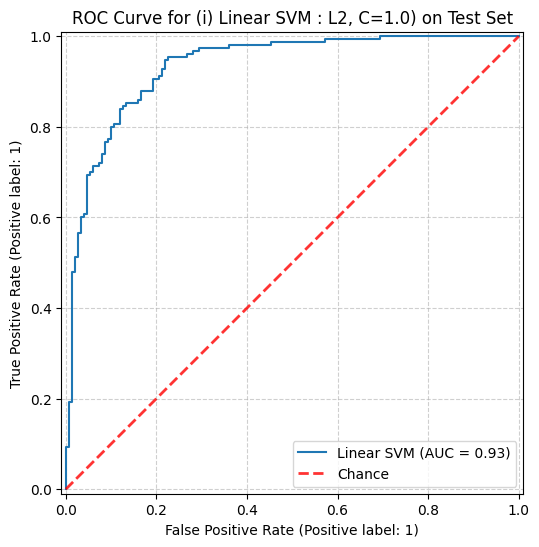

In [ ]:

fig, ax = plt.subplots(figsize=(8, 6))

disp = RocCurveDisplay.from_predictions(
    y_test_encoded,
    y_test_scores,
    name="Linear SVM",
    ax=ax,
    pos_label=1
)

disp.line_.set_label(f"Linear SVM (AUC = {auc_roc_test:.2f})")

ax.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=.8)
ax.set_title("ROC Curve for (i) Linear SVM : L2, C=1.0) on Test Set")
ax.legend(loc="lower right")
plt.grid(linestyle="--", alpha=0.6)
plt.show()


In [ ]:
performance_data = {
    'Metric': ['Training Time (seconds)', 'Validation F1-score', 'Validation AUC-ROC', 'Test F1-score', 'Test AUC-ROC'],
    'Value': [training_time_svm, f1_val, auc_roc_val, f1_test, auc_roc_test]
}

performance_df = pd.DataFrame(performance_data)
display(performance_df)

,Metric,Value
0,Training Time (seconds),0.220039
1,Validation F1-score,0.828947
2,Validation AUC-ROC,0.905600
3,Test F1-score,0.851613
4,Test AUC-ROC,0.933556


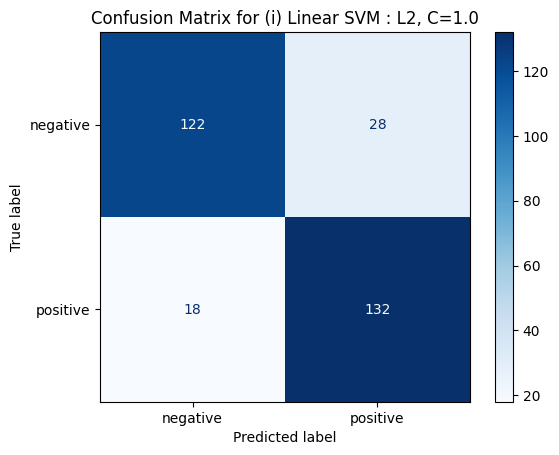

In [ ]:
y_test_pred = svm_classifier.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_test_pred, labels=svm_classifier.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for (i) Linear SVM : L2, C=1.0')
plt.show()

### (ii) Linear SVM with L1 Regularization, C =1.0

In [ ]:
svm_classifier_l1 = LinearSVC(C=1.0, penalty='l1', dual=False, random_state=42)

start_time_svm_l1 = time.time()
svm_classifier_l1.fit(X_train_tfidf, y_train)
end_time_svm_l1 = time.time()
training_time_svm_l1 = end_time_svm_l1 - start_time_svm_l1

# Validation Performance
y_val_pred_l1 = svm_classifier_l1.predict(X_val_tfidf)

f1_val_l1 = f1_score(y_val, y_val_pred_l1, pos_label='positive')

label_encoder = LabelEncoder()
y_val_encoded = label_encoder.fit_transform(y_val)
y_val_scores_l1 = svm_classifier_l1.decision_function(X_val_tfidf)

if list(label_encoder.classes_) == ['negative', 'positive']:
    auc_roc_val_l1 = roc_auc_score(y_val_encoded, y_val_scores_l1)
else:
    auc_roc_val_l1 = roc_auc_score(1 - y_val_encoded, -y_val_scores_l1)

# Test Performance
y_test_pred_l1 = svm_classifier_l1.predict(X_test_tfidf)
f1_test_l1 = f1_score(y_test, y_test_pred_l1, pos_label='positive')

y_test_encoded = label_encoder.transform(y_test)
y_test_scores_l1 = svm_classifier_l1.decision_function(X_test_tfidf)

if list(label_encoder.classes_) == ['negative', 'positive']:
    auc_roc_test_l1 = roc_auc_score(y_test_encoded, y_test_scores_l1)
else:
    auc_roc_test_l1 = roc_auc_score(1 - y_test_encoded, -y_test_scores_l1)

print(f"Linear SVM (L1) Training Time: {training_time_svm_l1:.2f} seconds")
print(f"Linear SVM (L1) Validation F1-score: {f1_val_l1:.3f}")
print(f"Linear SVM (L1) Validation AUC-ROC: {auc_roc_val_l1:.3f}")
print(f"Linear SVM (L1) Test F1-score: {f1_test_l1:.3f}")
print(f"Linear SVM (L1) Test AUC-ROC: {auc_roc_test_l1:.3f}")

Linear SVM (L1) Training Time: 0.12 seconds
Linear SVM (L1) Validation F1-score: 0.816
Linear SVM (L1) Validation AUC-ROC: 0.886
Linear SVM (L1) Test F1-score: 0.865
Linear SVM (L1) Test AUC-ROC: 0.924


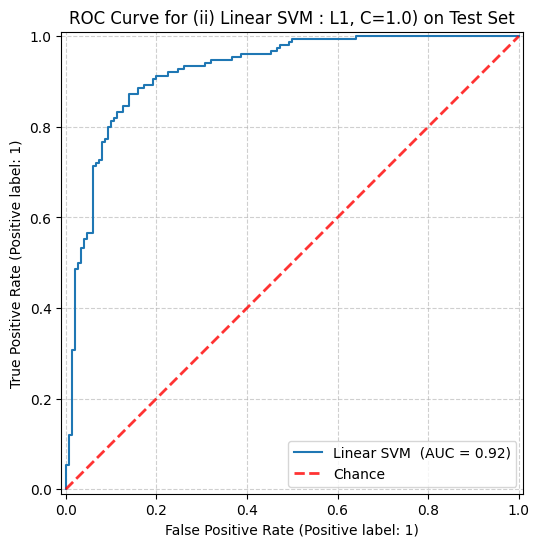

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test_encoded,
    y_test_scores_l1,
    name=f"Linear SVM ",
    ax=ax,
    pos_label=1
)

ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
ax.set_title('ROC Curve for (ii) Linear SVM : L1, C=1.0) on Test Set')
ax.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.6)
plt.show()

In [ ]:
performance_data_l1 = {
    'Metric': ['Training Time (seconds)', 'Validation F1-score', 'Validation AUC-ROC', 'Test F1-score', 'Test AUC-ROC'],
    'Value': [training_time_svm_l1, f1_val_l1, auc_roc_val_l1, f1_test_l1, auc_roc_test_l1]
}

performance_df_l1 = pd.DataFrame(performance_data_l1)
display(performance_df_l1)

,Metric,Value
0,Training Time (seconds),0.119723
1,Validation F1-score,0.815789
2,Validation AUC-ROC,0.885600
3,Test F1-score,0.864516
4,Test AUC-ROC,0.924133


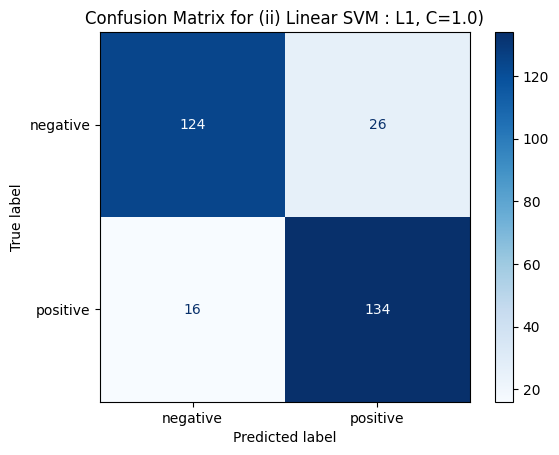

In [ ]:
y_test_pred_l1 = svm_classifier_l1.predict(X_test_tfidf)

cm_l1 = confusion_matrix(y_test, y_test_pred_l1, labels=svm_classifier_l1.classes_)

disp_l1 = ConfusionMatrixDisplay(confusion_matrix=cm_l1, display_labels=svm_classifier_l1.classes_)
disp_l1.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for (ii) Linear SVM : L1, C=1.0)')
plt.show()

### (iii) Linear SVM with L2 regularisation, C ∈ {0.01, 0.1, 1, 10, 100}

In [ ]:
c_values = [0.01, 0.1, 1, 10, 100]
results = []

label_encoder = LabelEncoder()
y_val_encoded = label_encoder.fit_transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

for c_val in c_values:
    print(f" C = {c_val}")

    svm_classifier_l2 = LinearSVC(C=c_val, penalty='l2', dual=False, random_state=42)

    # Train
    start_time = time.time()
    svm_classifier_l2.fit(X_train_tfidf, y_train)
    end_time = time.time()
    training_time = end_time - start_time

    # Validation Performance
    y_val_pred_l2 = svm_classifier_l2.predict(X_val_tfidf)
    f1_val = f1_score(y_val, y_val_pred_l2, pos_label='positive')
    y_val_scores_l2 = svm_classifier_l2.decision_function(X_val_tfidf)
    if list(label_encoder.classes_) == ['negative', 'positive']:
        auc_roc_val = roc_auc_score(y_val_encoded, y_val_scores_l2)
    else:
        auc_roc_val = roc_auc_score(1 - y_val_encoded, -y_val_scores_l2)

    # Test Performance
    y_test_pred_l2 = svm_classifier_l2.predict(X_test_tfidf)
    f1_test = f1_score(y_test, y_test_pred_l2, pos_label='positive')
    y_test_scores_l2 = svm_classifier_l2.decision_function(X_test_tfidf)
    if list(label_encoder.classes_) == ['negative', 'positive']:
        auc_roc_test = roc_auc_score(y_test_encoded, y_test_scores_l2)
    else:
        auc_roc_test = roc_auc_score(1 - y_test_encoded, -y_test_scores_l2)

    results.append({
        'C_Value': c_val,
        'Training Time (seconds)': training_time,
        'Validation F1-score': f1_val,
        'Validation AUC-ROC': auc_roc_val,
        'Test F1-score': f1_test,
        'Test AUC-ROC': auc_roc_test
    })

results_df = pd.DataFrame(results)
display(results_df)


 C = 0.01
 C = 0.1
 C = 1
 C = 10
 C = 100


,C_Value,Training Time (seconds),Validation F1-score,Validation AUC-ROC,Test F1-score,Test AUC-ROC
0,0.01,0.027666,0.786667,0.875467,0.829431,0.905244
1,0.10,0.034642,0.806557,0.889689,0.843854,0.921333
2,1.00,0.054270,0.828947,0.905600,0.851613,0.933556
3,10.00,0.152610,0.819672,0.904533,0.853503,0.931689
4,100.00,1.259631,0.818482,0.904533,0.853503,0.930933


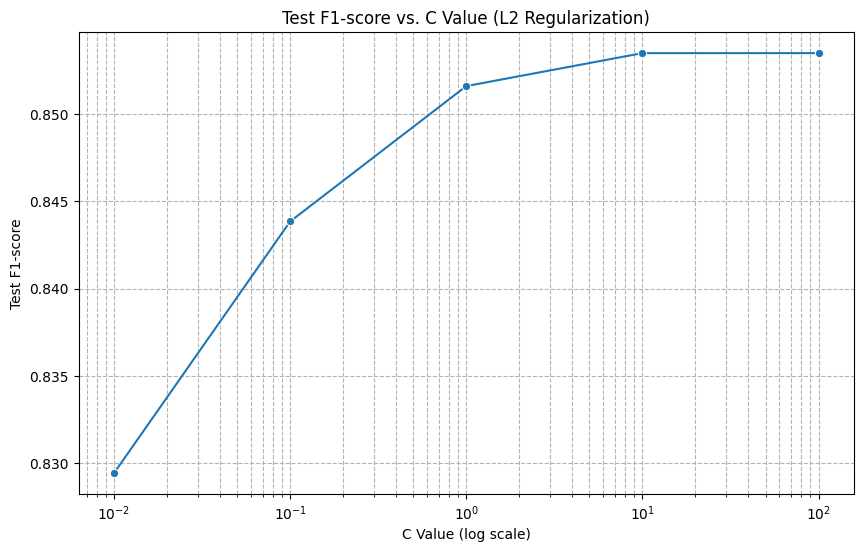

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='C_Value', y='Test F1-score', data=results_df, marker='o')
plt.xscale('log')
plt.title('Test F1-score vs. C Value (L2 Regularization)')
plt.xlabel('C Value (log scale)')
plt.ylabel('Test F1-score')
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

Confusion Matrix for C = 0.01


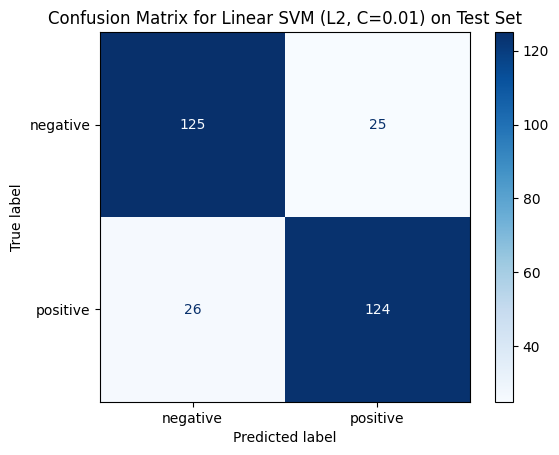

Confusion Matrix for C = 0.1


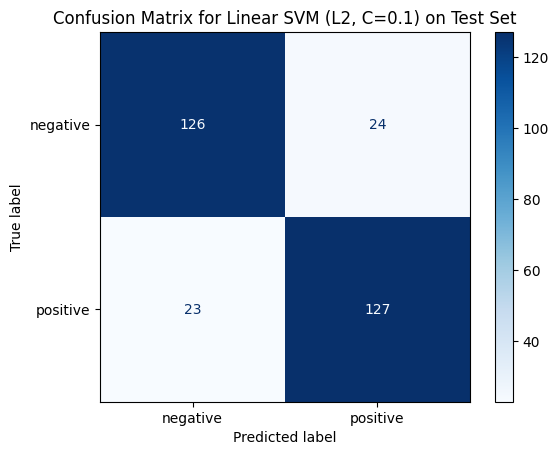

Confusion Matrix for C = 1


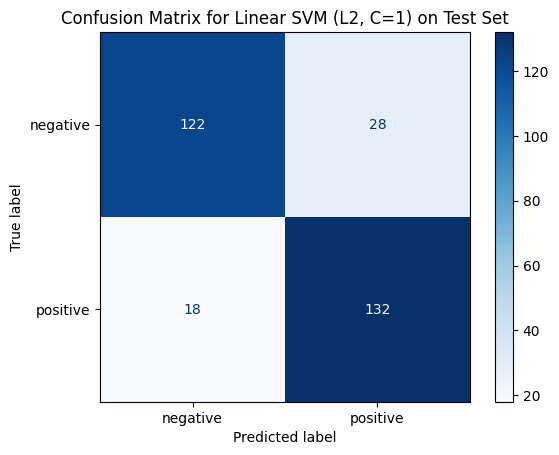

Confusion Matrix for C = 10


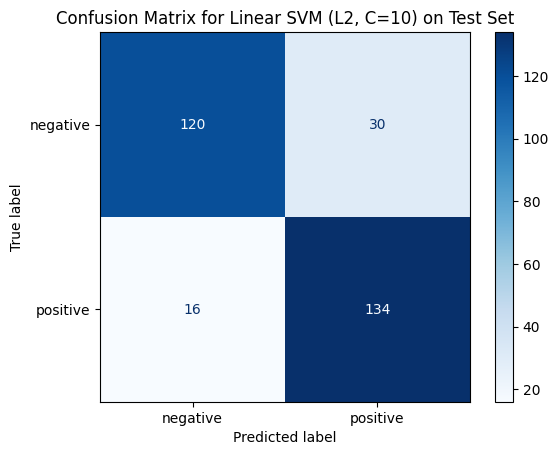

Confusion Matrix for C = 100


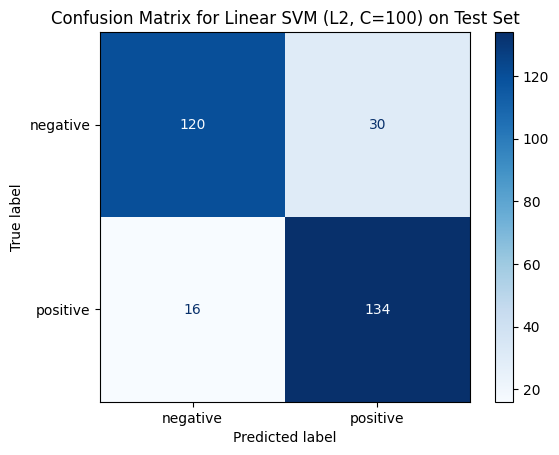

In [ ]:
c_values = [0.01, 0.1, 1, 10, 100]

for c_val in c_values:
    print(f"Confusion Matrix for C = {c_val}")

    svm_classifier_l2 = LinearSVC(C=c_val, penalty='l2', dual=False, random_state=42)

    # Train
    svm_classifier_l2.fit(X_train_tfidf, y_train)

    # Predict
    y_test_pred_l2 = svm_classifier_l2.predict(X_test_tfidf)

    cm_l2 = confusion_matrix(y_test, y_test_pred_l2, labels=svm_classifier_l2.classes_)
    disp_l2 = ConfusionMatrixDisplay(confusion_matrix=cm_l2, display_labels=svm_classifier_l2.classes_)
    disp_l2.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for Linear SVM (L2, C={c_val}) on Test Set')
    plt.show()

###(iv) RBF kernel SVM with optimal C from (iii) and γ ∈ {scale, auto, 0.001, 0.01} + Confusion Matrices

In [ ]:
sorted_results = results_df.sort_values(by=['Test F1-score', 'Test AUC-ROC'], ascending=[False, False])
best_c_for_rbf = sorted_results.iloc[0]['C_Value']

print(f"The best C-value: {best_c_for_rbf}")

The best C-value: 10.0


Evaluating RBF Kernel SVM with C = 10.0 for different gamma values:
  Training with gamma = scale


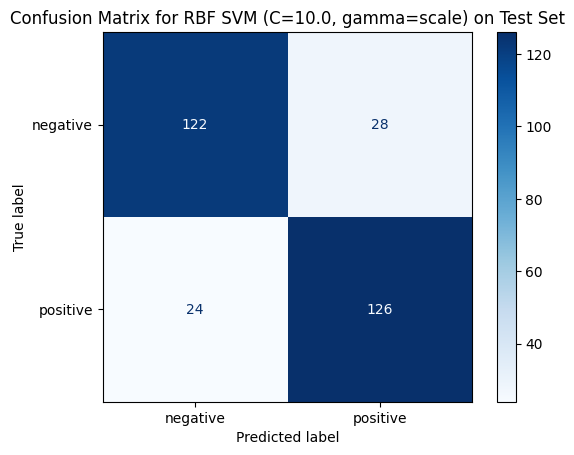

  Training with gamma = auto


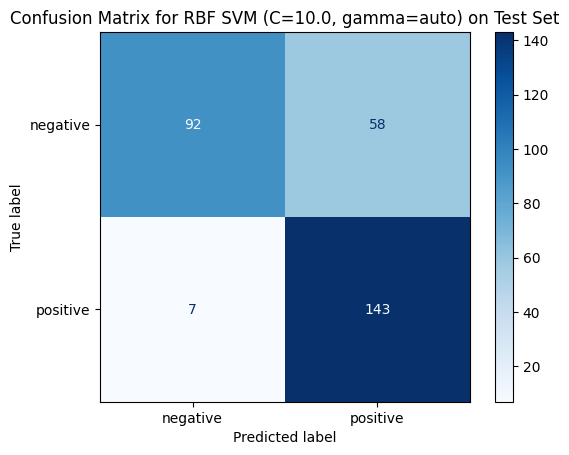

  Training with gamma = 0.001


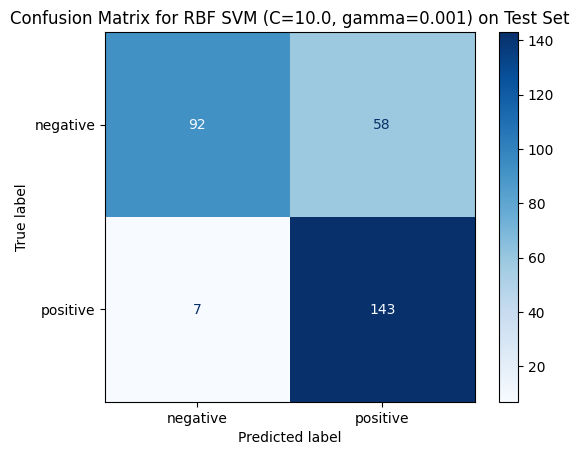

  Training with gamma = 0.01


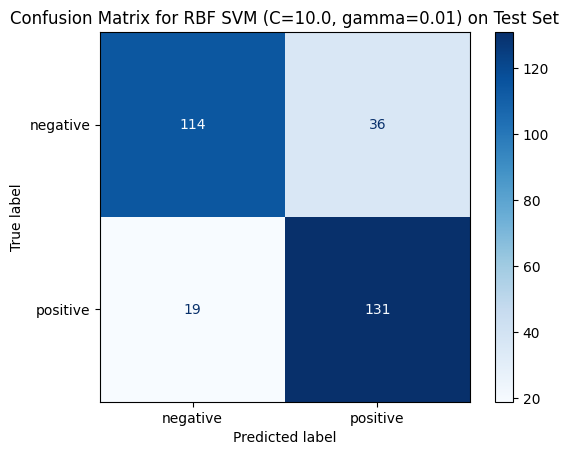

,C_Value,Gamma_Value,Training Time (seconds),Validation F1-score,Validation AUC-ROC,Test F1-score,Test AUC-ROC
0,10.0,scale,37.404185,0.805281,0.896578,0.828947,0.914044
1,10.0,auto,31.250803,0.798834,0.872667,0.814815,0.901244
2,10.0,0.001,31.477052,0.798834,0.872667,0.814815,0.901244
3,10.0,0.01,31.442747,0.789809,0.873778,0.826498,0.903867


In [ ]:
C_value = best_c_for_rbf
gamma_values = ['scale', 'auto', 0.001, 0.01]

rbf_results = []

label_encoder = LabelEncoder()
y_val_encoded = label_encoder.fit_transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

for gamma_val in gamma_values:
    print(f"  Training with gamma = {gamma_val}")
    rbf_svm_classifier = SVC(C=C_value, kernel='rbf', gamma=gamma_val, random_state=42, probability=True)

    # Train
    start_time = time.time()
    rbf_svm_classifier.fit(X_train_tfidf, y_train)
    end_time = time.time()
    training_time = end_time - start_time

    # Validation Performance
    y_val_pred_rbf = rbf_svm_classifier.predict(X_val_tfidf)
    f1_val = f1_score(y_val, y_val_pred_rbf, pos_label='positive')

    y_val_scores_rbf = rbf_svm_classifier.decision_function(X_val_tfidf)
    if list(label_encoder.classes_) == ['negative', 'positive']:
        auc_roc_val = roc_auc_score(y_val_encoded, y_val_scores_rbf)
    else:
        auc_roc_val = roc_auc_score(1 - y_val_encoded, -y_val_scores_rbf)

    # Test Performance
    y_test_pred_rbf = rbf_svm_classifier.predict(X_test_tfidf)
    f1_test = f1_score(y_test, y_test_pred_rbf, pos_label='positive')
    y_test_scores_rbf = rbf_svm_classifier.decision_function(X_test_tfidf)

    if list(label_encoder.classes_) == ['negative', 'positive']:
        auc_roc_test = roc_auc_score(y_test_encoded, y_test_scores_rbf)
    else:
        auc_roc_test = roc_auc_score(1 - y_test_encoded, -y_test_scores_rbf)

    rbf_results.append({
        'C_Value': C_value,
        'Gamma_Value': gamma_val,
        'Training Time (seconds)': training_time,
        'Validation F1-score': f1_val,
        'Validation AUC-ROC': auc_roc_val,
        'Test F1-score': f1_test,
        'Test AUC-ROC': auc_roc_test
    })

    # Confusion Matrix for RBF SVM on Test Set
    cm_rbf = confusion_matrix(y_test, y_test_pred_rbf, labels=rbf_svm_classifier.classes_)
    disp_rbf = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=rbf_svm_classifier.classes_)
    disp_rbf.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for RBF SVM (C={C_value}, gamma={gamma_val}) on Test Set')
    plt.show()

rbf_results_df = pd.DataFrame(rbf_results)
display(rbf_results_df)

##(b) Stage 3 Results

In [ ]:
#  results for Linear SVM with L2 Regularization (C=1.0)
linear_l2_c1_results = {
    'Configuration': 'Linear SVM L2 (C=1.0)',
    'Kernel': 'Linear',
    'Regularisation': 'L2',
    'C': 1.0,
    'Validation F1': performance_df.loc[performance_df['Metric'] == 'Validation F1-score', 'Value'].iloc[0],
    'Validation AUC-ROC': performance_df.loc[performance_df['Metric'] == 'Validation AUC-ROC', 'Value'].iloc[0],
    'Test F1': performance_df.loc[performance_df['Metric'] == 'Test F1-score', 'Value'].iloc[0],
    'Test AUC-ROC': performance_df.loc[performance_df['Metric'] == 'Test AUC-ROC', 'Value'].iloc[0],
    'Training Time': performance_df.loc[performance_df['Metric'] == 'Training Time (seconds)', 'Value'].iloc[0]
}

#  results for Linear SVM with L1 Regularization (C=1.0)
linear_l1_c1_results = {
    'Configuration': 'Linear SVM L1 (C=1.0)',
    'Kernel': 'Linear',
    'Regularisation': 'L1',
    'C': 1.0,
    'Validation F1': performance_df_l1.loc[performance_df_l1['Metric'] == 'Validation F1-score', 'Value'].iloc[0],
    'Validation AUC-ROC': performance_df_l1.loc[performance_df_l1['Metric'] == 'Validation AUC-ROC', 'Value'].iloc[0],
    'Test F1': performance_df_l1.loc[performance_df_l1['Metric'] == 'Test F1-score', 'Value'].iloc[0],
    'Test AUC-ROC': performance_df_l1.loc[performance_df_l1['Metric'] == 'Test AUC-ROC', 'Value'].iloc[0],
    'Training Time': performance_df_l1.loc[performance_df_l1['Metric'] == 'Training Time (seconds)', 'Value'].iloc[0]
}

#  results for Linear SVM with L2 Regularization (per C value)
linear_l2_various_c_results = []
for index, row in results_df.iterrows():
    linear_l2_various_c_results.append({
        'Configuration': f"Linear SVM L2 (C={row['C_Value']})",
        'Kernel': 'Linear',
        'Regularisation': 'L2',
        'C': row['C_Value'],
        'Validation F1': row['Validation F1-score'],
        'Validation AUC-ROC': row['Validation AUC-ROC'],
        'Test F1': row['Test F1-score'],
        'Test AUC-ROC': row['Test AUC-ROC'],
        'Training Time': row['Training Time (seconds)']
    })

#  results for RBF Kernel SVM (per gamma)
rbf_svm_results = []
for index, row in rbf_results_df.iterrows():
    rbf_svm_results.append({
        'Configuration': f"RBF SVM (C={row['C_Value']}, gamma={row['Gamma_Value']})",
        'Kernel': 'RBF',
        'Regularisation': 'L2',
        'C': row['C_Value'],
        'Validation F1': row['Validation F1-score'],
        'Validation AUC-ROC': row['Validation AUC-ROC'],
        'Test F1': row['Test F1-score'],
        'Test AUC-ROC': row['Test AUC-ROC'],
        'Training Time': row['Training Time (seconds)']
    })

all_results = [
    linear_l2_c1_results,
    linear_l1_c1_results
] + linear_l2_various_c_results + rbf_svm_results

summary_df = pd.DataFrame(all_results)

display(summary_df)

,Configuration,Kernel,Regularisation,C,Validation F1,Validation AUC-ROC,Test F1,Test AUC-ROC,Training Time
0,Linear SVM L2 (C=1.0),Linear,L2,1.00,0.828947,0.905600,0.851613,0.933556,0.220039
1,Linear SVM L1 (C=1.0),Linear,L1,1.00,0.815789,0.885600,0.864516,0.924133,0.119723
2,Linear SVM L2 (C=0.01),Linear,L2,0.01,0.786667,0.875467,0.829431,0.905244,0.027666
3,Linear SVM L2 (C=0.1),Linear,L2,0.10,0.806557,0.889689,0.843854,0.921333,0.034642
4,Linear SVM L2 (C=1.0),Linear,L2,1.00,0.828947,0.905600,0.851613,0.933556,0.054270
5,Linear SVM L2 (C=10.0),Linear,L2,10.00,0.819672,0.904533,0.853503,0.931689,0.152610
6,Linear SVM L2 (C=100.0),Linear,L2,100.00,0.818482,0.904533,0.853503,0.930933,1.259631
7,"RBF SVM (C=10, gamma=scale)",RBF,L2,10.00,0.805281,0.896578,0.828947,0.914044,32.039518
8,"RBF SVM (C=10, gamma=auto)",RBF,L2,10.00,0.798834,0.872667,0.814815,0.901244,29.580864
9,"RBF SVM (C=10, gamma=0.001)",RBF,L2,10.00,0.798834,0.872667,0.814815,0.901244,30.967849


# Stage 4 : Evaluation and Reporting

## (a) Best Performer Report

In [ ]:
best_performer = summary_df.loc[summary_df['Test F1'].idxmax()]

almost_best_performers = summary_df[summary_df['Test F1'] == best_performer['Test F1']]
if len(almost_best_performers) > 1:
    best_performer = almost_best_performers.loc[almost_best_performers['Test AUC-ROC'].idxmax()]

print(f"The best-performing configuration is: {best_performer['Configuration']}")
print(f"  Kernel: {best_performer['Kernel']}")
print(f"  Regularisation: {best_performer['Regularisation']}")
print(f"  C: {best_performer['C']}")
print(f"  Validation F1: {best_performer['Validation F1']:.3f}")
print(f"  Validation AUC-ROC: {best_performer['Validation AUC-ROC']:.3f}")
print(f"  Test F1: {best_performer['Test F1']:.3f}")
print(f"  Test AUC-ROC: {best_performer['Test AUC-ROC']:.3f}")
print(f"  Training Time: {best_performer['Training Time']:.2f} seconds")

The best-performing configuration is: Linear SVM L1 (C=1.0)
  Kernel: Linear
  Regularisation: L1
  C: 1.0
  Validation F1: 0.816
  Validation AUC-ROC: 0.886
  Test F1: 0.865
  Test AUC-ROC: 0.924
  Training Time: 0.12 seconds


Summary for the Best Performing Configuration: Linear SVM L1 (C=1.0)
------------------------------------------------------------

Classification Report on Test Set:
              precision    recall  f1-score   support

    negative       0.89      0.83      0.86       150
    positive       0.84      0.89      0.86       150

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300


Confusion Matrix on Test Set:


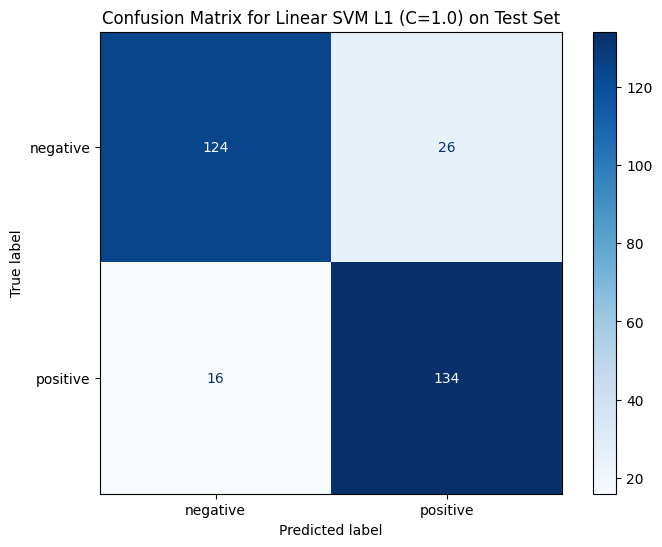


ROC Curve on Test Set:


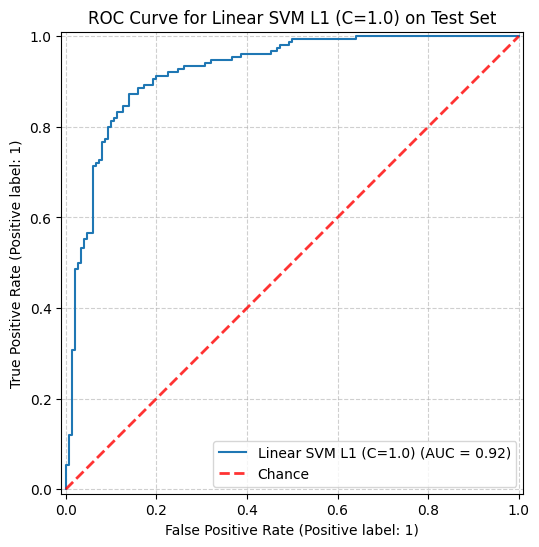


Precision-Recall Curve on Test Set:


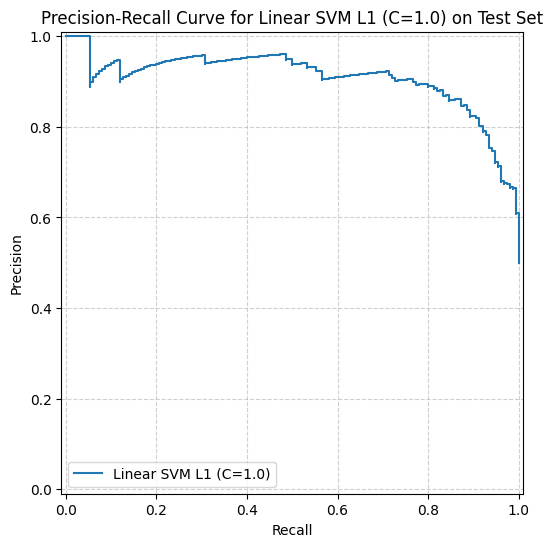

In [ ]:
best_c_value = best_performer['C']
kernel_type = best_performer['Kernel']

if kernel_type == 'RBF':
    config_string = best_performer['Configuration']
    match = re.search(r'gamma=([^)]+)', config_string)
    if match:
        best_gamma_value_str = match.group(1)
        if best_gamma_value_str.replace('.', '', 1).isdigit():
            best_gamma_value = float(best_gamma_value_str)
        else:
            best_gamma_value = best_gamma_value_str
    else:
        best_gamma_value = 'scale'

    best_model = SVC(C=best_c_value, kernel='rbf', gamma=best_gamma_value, random_state=42, probability=True)

elif kernel_type == 'Linear':
    penalty_type = best_performer['Regularisation'].lower()
    best_model = LinearSVC(C=best_c_value, penalty=penalty_type, dual=False, random_state=42)

else:
    raise ValueError(f"Unknown kernel type: {kernel_type}")

best_model.fit(X_train_tfidf, y_train)

y_test_pred_best = best_model.predict(X_test_tfidf)
y_test_scores_best = best_model.decision_function(X_test_tfidf)

label_encoder = LabelEncoder()
label_encoder.fit(y_train)
y_test_encoded_best = label_encoder.transform(y_test)

if list(label_encoder.classes_) == ['negative', 'positive']:
    pass
else:
    y_test_scores_best = -y_test_scores_best # 'positive' is mapped to 0, invert scores

print(f"Summary for the Best Performing Configuration: {best_performer['Configuration']}")
print("-" * 60)

#Classification Report
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred_best, target_names=label_encoder.classes_))

#Confusion Matrix
print("\nConfusion Matrix on Test Set:")
fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred_best, labels=best_model.classes_)
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp_cm.plot(cmap=plt.cm.Blues, ax=ax_cm)
ax_cm.set_title(f"Confusion Matrix for {best_performer['Configuration']} on Test Set")
plt.show()

#ROC Curve
print("\nROC Curve on Test Set:")
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test_encoded_best,
    y_test_scores_best,
    name=f"{best_performer['Configuration']}",
    ax=ax_roc,
    pos_label=1
)
ax_roc.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
ax_roc.set_title(f"ROC Curve for {best_performer['Configuration']} on Test Set")
ax_roc.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.6)
plt.show()

# 4. Precision-Recall Curve
print("\nPrecision-Recall Curve on Test Set:")
fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
precision, recall, _ = precision_recall_curve(y_test_encoded_best, y_test_scores_best, pos_label=1)
disp_pr = PrecisionRecallDisplay(precision=precision, recall=recall, estimator_name=best_performer['Configuration'])
disp_pr.plot(ax=ax_pr)
ax_pr.set_title(f"Precision-Recall Curve for {best_performer['Configuration']} on Test Set")
plt.grid(linestyle='--', alpha=0.6)
plt.show()

## (b) 5-fold stratified cross-validation

In [ ]:
X_combined_tfidf = vstack([X_train_tfidf, X_val_tfidf])
y_combined = pd.concat([y_train, y_val], ignore_index=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores_cv = []
auc_roc_scores_cv = []

label_encoder_cv = LabelEncoder()
y_combined_encoded = label_encoder_cv.fit_transform(y_combined)

for fold, (train_index, test_index) in enumerate(skf.split(X_combined_tfidf, y_combined_encoded)):
    print(f"\n--- Fold {fold+1}/5 ---")

    X_train_fold, X_test_fold = X_combined_tfidf[train_index], X_combined_tfidf[test_index]
    y_train_fold, y_test_fold = y_combined.iloc[train_index], y_combined.iloc[test_index]
    y_test_fold_encoded = y_combined_encoded[test_index]

    best_c_value = best_performer['C']
    kernel_type = best_performer['Kernel']

    if kernel_type == 'RBF':
        config_string = best_performer['Configuration']
        match = re.search(r'gamma=([^)]+)', config_string)
        if match:
            best_gamma_value_str = match.group(1)
            if best_gamma_value_str.replace('.', '', 1).isdigit():
                best_gamma_value = float(best_gamma_value_str)
            else:
                best_gamma_value = best_gamma_value_str
        else:
            best_gamma_value = 'scale'
        optimal_model_cv = SVC(C=best_c_value, kernel='rbf', gamma=best_gamma_value, random_state=42, probability=True)

    elif kernel_type == 'Linear':
        penalty_type = best_performer['Regularisation'].lower()
        optimal_model_cv = LinearSVC(C=best_c_value, penalty=penalty_type, dual=False, random_state=42)
    else:
        raise ValueError(f"Unknown kernel type: {kernel_type}")

    optimal_model_cv.fit(X_train_fold, y_train_fold)

    y_pred_fold = optimal_model_cv.predict(X_test_fold)
    y_scores_fold = optimal_model_cv.decision_function(X_test_fold)

    if list(label_encoder_cv.classes_) == ['negative', 'positive']:
        pass
    else:
        y_scores_fold = -y_scores_fold

    f1_fold = f1_score(y_test_fold, y_pred_fold, pos_label='positive')
    auc_roc_fold = roc_auc_score(y_test_fold_encoded, y_scores_fold)

    f1_scores_cv.append(f1_fold)
    auc_roc_scores_cv.append(auc_roc_fold)

    print(f"F1-score (positive class) for Fold {fold+1}: {f1_fold:.3f}")
    print(f"AUC-ROC for Fold {fold+1}: {auc_roc_fold:.3f}")



--- Fold 1/5 ---
F1-score (positive class) for Fold 1: 0.844
AUC-ROC for Fold 1: 0.910

--- Fold 2/5 ---
F1-score (positive class) for Fold 2: 0.800
AUC-ROC for Fold 2: 0.874

--- Fold 3/5 ---
F1-score (positive class) for Fold 3: 0.814
AUC-ROC for Fold 3: 0.892

--- Fold 4/5 ---
F1-score (positive class) for Fold 4: 0.811
AUC-ROC for Fold 4: 0.890

--- Fold 5/5 ---
F1-score (positive class) for Fold 5: 0.803
AUC-ROC for Fold 5: 0.881


In [ ]:
mean_f1_cv = np.mean(f1_scores_cv)
std_f1_cv = np.std(f1_scores_cv)

mean_auc_roc_cv = np.mean(auc_roc_scores_cv)
std_auc_roc_cv = np.std(auc_roc_scores_cv)

In [ ]:
summary_report_data = [
    {
        'Metric': 'Cross-Validation F1-score (Mean +/- Std)',
        'Value': f"{mean_f1_cv:.3f} (+/- {std_f1_cv:.3f})"
    },
    {
        'Metric': 'Cross-Validation AUC-ROC (Mean +/- Std)',
        'Value': f"{mean_auc_roc_cv:.3f} (+/- {std_auc_roc_cv:.3f})"
    },
    {
        'Metric': 'Best Model Test F1-score',
        'Value': f"{best_performer['Test F1']:.3f}"
    },
    {
        'Metric': 'Best Model Test AUC-ROC',
        'Value': f"{best_performer['Test AUC-ROC']:.3f}"
    },
    {
        'Metric': 'Best Model Configuration',
        'Value': best_performer['Configuration']
    },
    {
        'Metric': 'Best Model Kernel',
        'Value': best_performer['Kernel']
    },
    {
        'Metric': 'Best Model Regularisation',
        'Value': best_performer['Regularisation']
    },
    {
        'Metric': 'Best Model C value',
        'Value': best_performer['C']
    },
    {
        'Metric': 'Best Model Training Time (seconds)',
        'Value': f"{best_performer['Training Time']:.2f}"
    }
]

summary_report_df = pd.DataFrame(summary_report_data)
display(summary_report_df)

,Metric,Value
0,Cross-Validation F1-score (Mean +/- Std),0.814 (+/- 0.016)
1,Cross-Validation AUC-ROC (Mean +/- Std),0.889 (+/- 0.012)
2,Best Model Test F1-score,0.865
3,Best Model Test AUC-ROC,0.924
4,Best Model Configuration,Linear SVM L1 (C=1.0)
5,Best Model Kernel,Linear
6,Best Model Regularisation,L1
7,Best Model C value,1.0
8,Best Model Training Time (seconds),0.12


##(c) Embedding Features vs TF-IDF

###GloVe

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


F1-score (positive class) on Test Set (GloVe L1 SVM): 0.706
AUC-ROC on Test Set (GloVe L1 SVM): 0.775
Training Time (GloVe L1 SVM): 0.44 seconds

Classification Report on Test Set (GloVe L1 SVM):
              precision    recall  f1-score   support

    negative       0.70      0.77      0.73       150
    positive       0.74      0.67      0.71       150

    accuracy                           0.72       300
   macro avg       0.72      0.72      0.72       300
weighted avg       0.72      0.72      0.72       300


Confusion Matrix on Test Set (GloVe L1 SVM):


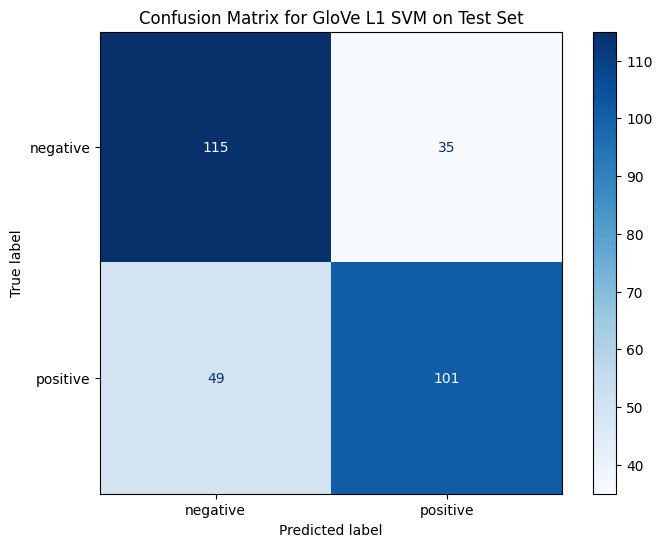


ROC Curve on Test Set (GloVe L1 SVM):


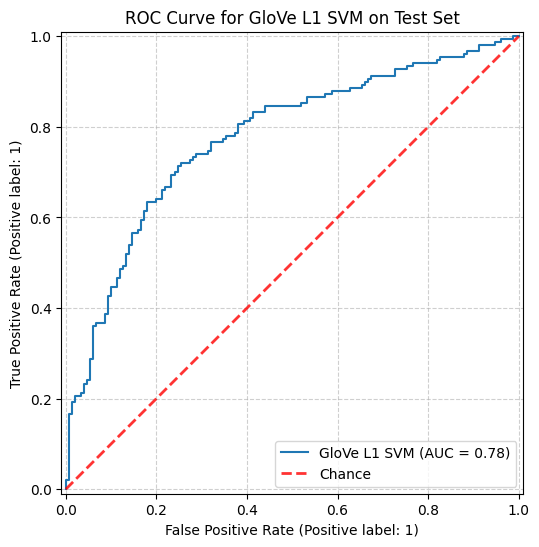


Precision-Recall Curve on Test Set (GloVe L1 SVM):


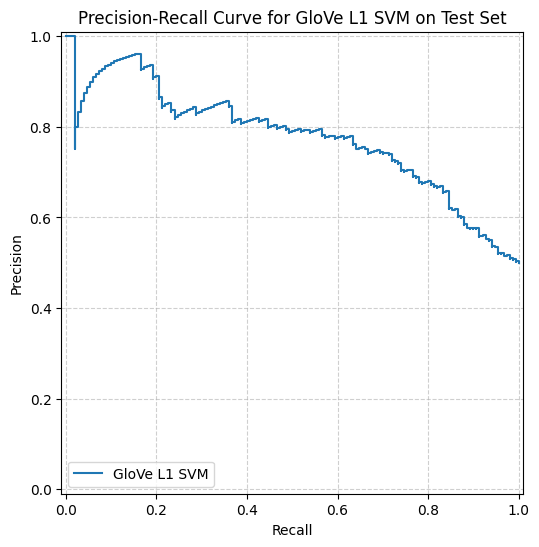

In [ ]:
svm_glove_l1 = LinearSVC(C=1.0, penalty='l1', dual=False, random_state=42)

start_time_glove_svm = time.time()
svm_glove_l1.fit(X_train_glove_embeddings, y_train)
end_time_glove_svm = time.time()
training_time_glove_svm = end_time_glove_svm - start_time_glove_svm

y_pred_glove_l1 = svm_glove_l1.predict(X_test_glove_embeddings)

y_scores_glove_l1 = svm_glove_l1.decision_function(X_test_glove_embeddings)

label_encoder = LabelEncoder()
label_encoder.fit(y_train)
y_test_encoded_glove = label_encoder.transform(y_test)


if list(label_encoder.classes_) == ['negative', 'positive']:
    pass
else:
    y_scores_glove_l1 = -y_scores_glove_l1

#  F1-score
f1_glove_test = f1_score(y_test, y_pred_glove_l1, pos_label='positive')
print(f"F1-score (positive class) on Test Set (GloVe L1 SVM): {f1_glove_test:.3f}")

# AUC-ROC
auc_roc_glove_test = roc_auc_score(y_test_encoded_glove, y_scores_glove_l1)
print(f"AUC-ROC on Test Set (GloVe L1 SVM): {auc_roc_glove_test:.3f}")
print(f"Training Time (GloVe L1 SVM): {training_time_glove_svm:.2f} seconds")

print("\nClassification Report on Test Set (GloVe L1 SVM):")
print(classification_report(y_test, y_pred_glove_l1, target_names=label_encoder.classes_))

# Confusion Matrix
print("\nConfusion Matrix on Test Set (GloVe L1 SVM):")
cm_glove = confusion_matrix(y_test, y_pred_glove_l1, labels=svm_glove_l1.classes_)
disp_cm_glove = ConfusionMatrixDisplay(confusion_matrix=cm_glove, display_labels=svm_glove_l1.classes_)
fig_cm_glove, ax_cm_glove = plt.subplots(figsize=(8, 6))
disp_cm_glove.plot(cmap=plt.cm.Blues, ax=ax_cm_glove)
ax_cm_glove.set_title("Confusion Matrix for GloVe L1 SVM on Test Set")
plt.show()

# ROC Curve
print("\nROC Curve on Test Set (GloVe L1 SVM):")
fig_roc_glove, ax_roc_glove = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test_encoded_glove,
    y_scores_glove_l1,
    name="GloVe L1 SVM",
    ax=ax_roc_glove,
    pos_label=1
)
ax_roc_glove.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
ax_roc_glove.set_title("ROC Curve for GloVe L1 SVM on Test Set")
ax_roc_glove.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.6)
plt.show()

# Precision-Recall Curve
print("\nPrecision-Recall Curve on Test Set (GloVe L1 SVM):")
fig_pr_glove, ax_pr_glove = plt.subplots(figsize=(8, 6))
precision_glove, recall_glove, _ = precision_recall_curve(y_test_encoded_glove, y_scores_glove_l1, pos_label=1)
disp_pr_glove = PrecisionRecallDisplay(precision=precision_glove, recall=recall_glove, estimator_name="GloVe L1 SVM")
disp_pr_glove.plot(ax=ax_pr_glove)
ax_pr_glove.set_title("Precision-Recall Curve for GloVe L1 SVM on Test Set")
plt.grid(linestyle='--', alpha=0.6)
plt.show()

### Word2Vec

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


F1-score (positive class) on Test Set (Word2Vec L1 SVM): 0.687
AUC-ROC on Test Set (Word2Vec L1 SVM): 0.701
Training Time (Word2Vec L1 SVM): 0.59 seconds

Classification Report on Test Set (Word2Vec L1 SVM):
              precision    recall  f1-score   support

    negative       0.69      0.59      0.64       150
    positive       0.64      0.74      0.69       150

    accuracy                           0.66       300
   macro avg       0.67      0.66      0.66       300
weighted avg       0.67      0.66      0.66       300


Confusion Matrix on Test Set (Word2Vec L1 SVM):


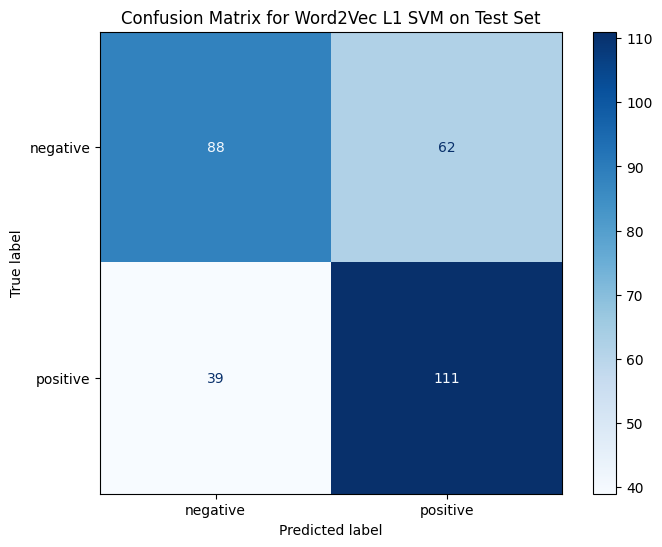


ROC Curve on Test Set (Word2Vec L1 SVM):


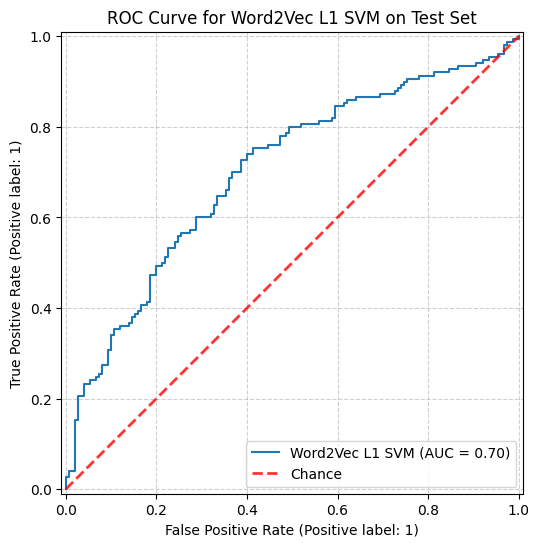


Precision-Recall Curve on Test Set (Word2Vec L1 SVM):


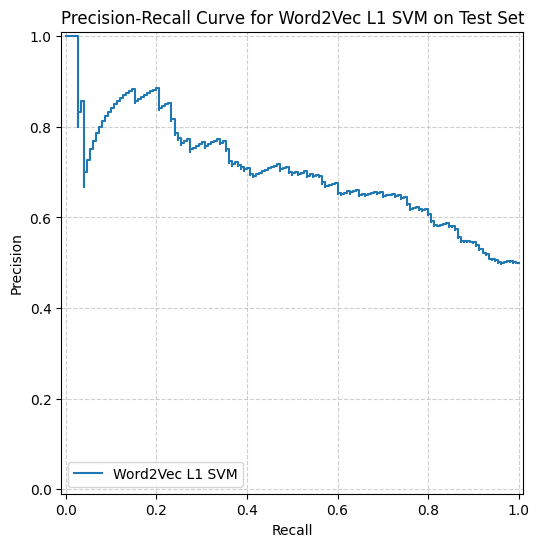

In [ ]:
svm_w2v_l1 = LinearSVC(C=1.0, penalty='l1', dual=False, random_state=42)

start_time_w2v_svm = time.time()
svm_w2v_l1.fit(X_train_w2v_embeddings, y_train)
end_time_w2v_svm = time.time()
training_time_w2v_svm = end_time_w2v_svm - start_time_w2v_svm

y_pred_w2v_l1 = svm_w2v_l1.predict(X_test_w2v_embeddings)
y_scores_w2v_l1 = svm_w2v_l1.decision_function(X_test_w2v_embeddings)

label_encoder = LabelEncoder()
label_encoder.fit(y_train)
y_test_encoded_w2v = label_encoder.transform(y_test)

if list(label_encoder.classes_) == ['negative', 'positive']:
    pass
else:
    y_scores_w2v_l1 = -y_scores_w2v_l1

# F1-score
f1_w2v_test = f1_score(y_test, y_pred_w2v_l1, pos_label='positive')
print(f"F1-score (positive class) on Test Set (Word2Vec L1 SVM): {f1_w2v_test:.3f}")

# AUC-ROC
auc_roc_w2v_test = roc_auc_score(y_test_encoded_w2v, y_scores_w2v_l1)
print(f"AUC-ROC on Test Set (Word2Vec L1 SVM): {auc_roc_w2v_test:.3f}")
print(f"Training Time (Word2Vec L1 SVM): {training_time_w2v_svm:.2f} seconds")

# classification report
print("\nClassification Report on Test Set (Word2Vec L1 SVM):")
print(classification_report(y_test, y_pred_w2v_l1, target_names=label_encoder.classes_))

# confusion matrix
print("\nConfusion Matrix on Test Set (Word2Vec L1 SVM):")
cm_w2v = confusion_matrix(y_test, y_pred_w2v_l1, labels=svm_w2v_l1.classes_)
disp_cm_w2v = ConfusionMatrixDisplay(confusion_matrix=cm_w2v, display_labels=svm_w2v_l1.classes_)
fig_cm_w2v, ax_cm_w2v = plt.subplots(figsize=(8, 6))
disp_cm_w2v.plot(cmap=plt.cm.Blues, ax=ax_cm_w2v)
ax_cm_w2v.set_title("Confusion Matrix for Word2Vec L1 SVM on Test Set")
plt.show()

# ROC Curve
print("\nROC Curve on Test Set (Word2Vec L1 SVM):")
fig_roc_w2v, ax_roc_w2v = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test_encoded_w2v,
    y_scores_w2v_l1,
    name="Word2Vec L1 SVM",
    ax=ax_roc_w2v,
    pos_label=1
)
ax_roc_w2v.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
ax_roc_w2v.set_title("ROC Curve for Word2Vec L1 SVM on Test Set")
ax_roc_w2v.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.6)
plt.show()

# Precision-Recall Curve
print("\nPrecision-Recall Curve on Test Set (Word2Vec L1 SVM):")
fig_pr_w2v, ax_pr_w2v = plt.subplots(figsize=(8, 6))
precision_w2v, recall_w2v, _ = precision_recall_curve(y_test_encoded_w2v, y_scores_w2v_l1, pos_label=1)
disp_pr_w2v = PrecisionRecallDisplay(precision=precision_w2v, recall=recall_w2v, estimator_name="Word2Vec L1 SVM")
disp_pr_w2v.plot(ax=ax_pr_w2v)
ax_pr_w2v.set_title("Precision-Recall Curve for Word2Vec L1 SVM on Test Set")
plt.grid(linestyle='--', alpha=0.6)
plt.show()

### Sentence Transformer

In [ ]:
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')
X_train_st_embeddings = sentence_model.encode(X_train['lemmatized_content_str'].tolist(), show_progress_bar=False)
X_val_st_embeddings = sentence_model.encode(X_val['lemmatized_content_str'].tolist(), show_progress_bar=False)
X_test_st_embeddings = sentence_model.encode(X_test['lemmatized_content_str'].tolist(), show_progress_bar=False)


svm_st_l1 = LinearSVC(C=1.0, penalty='l1', dual=False, random_state=42)

start_time_st_svm = time.time()
svm_st_l1.fit(X_train_st_embeddings, y_train)
end_time_st_svm = time.time()
training_time_st_svm = end_time_st_svm - start_time_st_svm


y_pred_st_l1 = svm_st_l1.predict(X_test_st_embeddings)
y_scores_st_l1 = svm_st_l1.decision_function(X_test_st_embeddings)

label_encoder = LabelEncoder()
label_encoder.fit(y_train)
y_test_encoded_st = label_encoder.transform(y_test)

if list(label_encoder.classes_) == ['negative', 'positive']:
    pass
else:
    y_scores_st_l1 = -y_scores_st_l1

# F1-score
f1_st_test = f1_score(y_test, y_pred_st_l1, pos_label='positive')
print(f"F1-score (positive class) on Test Set (Sentence Transformer L1 SVM): {f1_st_test:.3f}")

# AUC-ROC
auc_roc_st_test = roc_auc_score(y_test_encoded_st, y_scores_st_l1)
print(f"AUC-ROC on Test Set (Sentence Transformer L1 SVM): {auc_roc_st_test:.3f}")
print(f"Training Time (Sentence Transformer L1 SVM): {training_time_st_svm:.2f} seconds")

# classification report
print("\nClassification Report on Test Set (Sentence Transformer L1 SVM):")
print(classification_report(y_test, y_pred_st_l1, target_names=label_encoder.classes_))

# confusion matrix
print("\nConfusion Matrix on Test Set (Sentence Transformer L1 SVM):")
cm_st = confusion_matrix(y_test, y_pred_st_l1, labels=svm_st_l1.classes_)
disp_cm_st = ConfusionMatrixDisplay(confusion_matrix=cm_st, display_labels=svm_st_l1.classes_)
fig_cm_st, ax_cm_st = plt.subplots(figsize=(8, 6))
disp_cm_st.plot(cmap=plt.cm.Blues, ax=ax_cm_st)
ax_cm_st.set_title("Confusion Matrix for Sentence Transformer L1 SVM on Test Set")
plt.show()

# ROC Curve
print("\nROC Curve on Test Set (Sentence Transformer L1 SVM):")
fig_roc_st, ax_roc_st = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test_encoded_st,
    y_scores_st_l1,
    name="Sentence Transformer L1 SVM",
    ax=ax_roc_st,
    pos_label=1
)
ax_roc_st.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
ax_roc_st.set_title("ROC Curve for Sentence Transformer L1 SVM on Test Set")
ax_roc_st.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.6)
plt.show()

# Precision-Recall Curve
print("\nPrecision-Recall Curve on Test Set (Sentence Transformer L1 SVM):")
fig_pr_st, ax_pr_st = plt.subplots(figsize=(8, 6))
precision_st, recall_st, _ = precision_recall_curve(y_test_encoded_st, y_scores_st_l1, pos_label=1)
disp_pr_st = PrecisionRecallDisplay(precision=precision_st, recall=recall_st, estimator_name="Sentence Transformer L1 SVM")
disp_pr_st.plot(ax=ax_pr_st)
ax_pr_st.set_title("Precision-Recall Curve for Sentence Transformer L1 SVM on Test Set")
plt.grid(linestyle='--', alpha=0.6)
plt.show()

In [ ]:
auc_roc_comparison_data = {
    'Embedding Type': ['Word2Vec', 'Sentence Transformer', 'GloVe'],
    'AUC-ROC': [auc_roc_w2v_test, auc_roc_st_test, auc_roc_glove_test]
}

auc_roc_comparison_df = pd.DataFrame(auc_roc_comparison_data)
display(auc_roc_comparison_df)

,Embedding Type,AUC-ROC
0,Word2Vec,0.700933
1,Sentence Transformer,0.775644
2,GloVe,0.775378
